# Step 1: Load Data

In [ ]:
# Step 1: Load Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/Combined_dataset.csv")

print("Dataset Shape:")
print(df.shape)
print("Column Names:")
print(df.columns.tolist())

Dataset Shape:
(1000, 24)

Column Names:
['product_id', 'title', 'product_description', 'rating', 'ratings_count', 'initial_price', 'discount', 'final_price', 'currency', 'images', 'delivery_options', 'product_details', 'breadcrumbs', 'product_specifications', 'amount_of_stars', 'what_customers_said', 'seller_name', 'sizes', 'videos', 'seller_information', 'variations', 'best_offer', 'more_offers', 'category']


# Step 2: Understand Data

In [18]:
print("Data Types:")
print(df.dtypes)
print("Dataset Information:")
df.info()
print("Summary Statistics:")
df.describe()
print("Missing Values:")
print(df.isnull().sum())

Data Types:
product_id                  int64
title                      object
product_description        object
rating                    float64
ratings_count               int64
initial_price               int64
discount                  float64
final_price                object
currency                   object
images                     object
delivery_options           object
product_details            object
breadcrumbs                object
product_specifications     object
amount_of_stars            object
what_customers_said        object
seller_name                object
sizes                      object
videos                     object
seller_information         object
variations                 object
best_offer                 object
more_offers                object
category                   object
dtype: object
Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column                  No

# Step 3: Data Cleaning

In [22]:
#Convert Price Columns
df["initial_price"] = pd.to_numeric(
    df["initial_price"],
    errors="coerce"
)

df["final_price"] = pd.to_numeric(
    df["final_price"],
    errors="coerce"
)

print("Price columns converted successfully")

#Handle Missing Values
df.fillna(0, inplace=True)

print("Missing values handled")

#Remove Duplicates
print("Duplicate Rows Before Cleaning:")
print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Duplicates Removed Successfully")

Price columns converted successfully
Missing values handled
Duplicate Rows Before Cleaning:
0
Duplicates Removed Successfully


# Step 4: Feature Engineering

In [27]:
#Create Price Difference
df["price_difference"] = (
    df["initial_price"] -
    df["final_price"]
)

print("Price Difference Column Created")

#Create Popularity Metric
df["popularity_metric"] = (
    df["rating"] *
    df["ratings_count"]
)

print("Popularity Metric Created")

#View New Columns
print(df[
    ["price_difference",
     "popularity_metric"]
].head())

Price Difference Column Created
Popularity Metric Created
   price_difference  popularity_metric
0            3995.0               57.0
1            2899.0              301.5
2            2999.0              994.4
3            1675.0             4628.8
4            2899.0               56.4


# Step 5: Analysis

In [29]:
#Univariate Analysis
#Rating Statistics
print("Rating Statistics:")
print(df["rating"].describe())

Rating Statistics:
count    1000.0000
mean        3.6215
std         1.3744
min         0.0000
25%         3.7000
50%         4.1000
75%         4.3000
max         5.0000
Name: rating, dtype: float64


In [30]:
#Bivariate Analysis
#Rating and Final Price
print("Rating and Final Price:")
print(
    df[
        ["rating",
         "final_price"]
    ].head()
)

Rating and Final Price:
   rating  final_price
0     3.8          0.0
1     4.5          0.0
2     4.4          0.0
3     4.4          0.0
4     4.7          0.0


In [32]:
#Category Analysis
#Top Categories
print("Top 10 Categories:")
print(
    df["category"]
    .value_counts()
    .head(10)
)

Top 10 Categories:
category
tops            122
dresses         100
shirts           97
jeans            57
sports-shoes     51
tshirts          39
earrings         34
sweaters         34
jackets          29
casual-shoes     23
Name: count, dtype: int64


# Step 6: Visualization

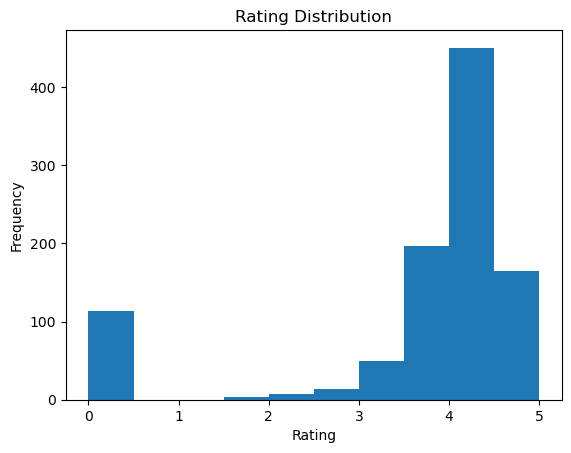

In [41]:
#Histogram
# Create histogram for ratings

plt.hist(df["rating"])

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

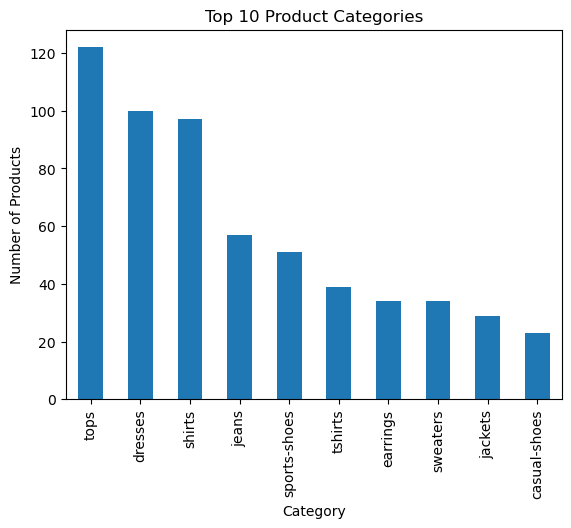

In [ ]:
#Bar Chart
# Count the number of products in each category
top_categories = df["category"].value_counts().head(10)

# Create bar chart
top_categories.plot(kind="bar")

plt.title("Top 10 Product Categories")
plt.xlabel("Category")
plt.ylabel("Number of Products")

plt.show()

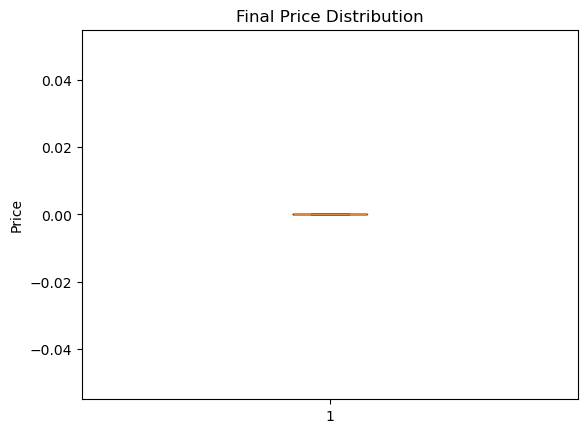

In [37]:
#Boxplot
# Create boxplot for final price

plt.boxplot(df["final_price"])

plt.title("Final Price Distribution")
plt.ylabel("Price")

plt.show()

# Step 7: Insights

# Key Findings

1. Product details include price, rating, and product category.

2. In the data cleaning phase, the missing values and duplicate records were handled.

3. A new column, price_difference, was created to hold the difference between the final price and the original price.

4. The popularity_metric column was created using product ratings and ratings count.

5. The analysis of the product categories showed that certain categories have a higher count of products.

# Business Implications

6. More popular products may get more customer purchases.

7. Analyzing the ratings may help the business to gain insights into customer preferences and needs.

8. Analyzing the product count in each category helps the business to understand how the products are spread in the categories.

9. Understanding the price difference may provide insights into how discounts are applied to products.